**Importing libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pycaret.regression import *

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)


**Load Kaggle dataset**

In [2]:
simple_df = pd.read_csv("data/SimpleHouse.csv")
simple_df.head()

complex_df = pd.read_csv("data/ComplexHouse.csv")
complex_df.head()

,Unnamed: 0,Id,PropertyLocationStreet1,PropertyLocationStreet2,PropertyCity,CountyFIPS,PropertyZip,OwnerName,OwnerMailAddress1,OwnerMailAddress2,OwnerCity,OwnerState,OwnerZip,CitizensTerritory,ConstructionType,NumberOfStories,NumberOfFamilies,YearBuilt,YearofRoof,YearofRoofVerified,RoofMaterial,AdjSquareFeet,Occupancy,NumberOfMonthsUnoccupied,PPC,BCEG,TypeOfResidence,FloorOfResidence,FloridaWindpool,DistancetoCoast,DistancetoSinkhole,DistancetoHydrant,DistancetoFireDepartment,FireDistrict,RespondingFireDepartment,CentralStationAlarm,AutomaticSprinklers,NumberOfClaims,LocationWindSpeed,DesignWindSpeed,InternalPressureDesign,WindborneDebrisRegion,Terrain,RoofDeckAttachment,RoofCover,RooftoWallconnection,SecondaryWaterResistance,OpeningProtection,RoofShape,DesignExposure,ValueofHome,UnattachedStructure,NoPriorInsurance,Condemned,FarmsNRanches,FraternityorSorority,Vacant,FloodZone,ConstructedOverWater,BuiltonLandfills,HomeDayCare,Pool,ParcelSize,ImprovementQuality,ImprovementQualityDate,NumberOfBuildings,NumberOfUnits,Crime,PoliceID,FireID,CountyName,PropertyState,CentroidLatitude,CentroidLongitude,IsHciProperty,CoastLatitude,CoastLongitude,FireStationLatitude,FireStationLongitude,SinkholeLatitude,SinkholeLongitude,SinkholeId,SinkholeAddress,FloodZoneRiskLevel,EffectiveYearBuilt,NumberOfBusiness,HydrantLatitude,HydrantLongitude,LastSalePrice,LastSaleDate,Homestead,FloodzoneLastUpdatedDate,StateParcelId,AssesmentYear,Geometry,TTTerritory
0,0,120210f35317ca697,503 LAKE LOUISE CIR,19-201,NAPLES,21.0,34110,"BOLTZ, LARRY P & SANDRA A",3739 WRENS NEST BLVD,NaN,MAUMEE,OH,43537.0,541.0,NaN,NaN,NaN,1988.0,NaN,False,NaN,1384.0,NaN,NaN,NaN,NaN,CONDO STACKED,NaN,NaN,2956.8,NaN,NaN,1.20,50.0,NORTH NAPLES FIRE DEPARTMENT AND RESCUE STATION 43,NaN,NaN,NaN,129.0,NaN,NaN,True,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200840.0,NaN,NaN,NaN,NaN,NaN,NaN,A:100,NaN,NaN,NaN,NaN,NaN,ABOVE AVERAGE,118.0,NaN,1.0,NaN,NaN,50.0,COLLIER,FL,26.30478,-81.81791,NaN,NaN,NaN,26.32210,-81.81959,NaN,NaN,NaN,NaN,NaN,1988.0,NaN,NaN,NaN,NaN,NaN,False,2017-05-12 00:00:00,C21-000-188-9852-8,2015.0,NaN,541-0
1,0,12086db272d757be6,5934 NW 7 PL,NaN,MIAMI,86.0,33127,LILIANE MORISSETTE,5934 NW 7 PL,NaN,MIAMI,FL,33127.0,32.0,NaN,NaN,NaN,2004.0,NaN,False,NaN,1534.0,NaN,NaN,1,2.0,SINGLE FAMILY,NaN,NaN,-99.0,9.56,195.70,0.98,626.0,MIAMI FIRE DEPARTMENT AND RESCUE STATION 9,NaN,NaN,NaN,146.0,NaN,NaN,True,HVHZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,164994.0,NaN,NaN,NaN,NaN,NaN,NaN,A:100,NaN,NaN,NaN,NaN,4880.0,ABOVE AVERAGE,212.0,1.0,1.0,NaN,626.0,626.0,MIAMI-DADE,FL,25.82994,-80.21004,NaN,25.83218,-80.18086,25.83300,-80.19468,25.96256,-80.16641,2783.0,NaN,NaN,2004.0,NaN,25.83045,-80.21022,NaN,NaN,True,2017-12-08 00:00:00,C23-000-198-3578-4,2015.0,NaN,032-0
2,0,12057c35a22b0865c,5713 PALM RIVER RD,NaN,TAMPA,57.0,33619,PADRON LUIS A,5713 PALM RIVER RD,NaN,TAMPA,FL,33619.0,80.0,MASONRY,NaN,NaN,2005.0,NaN,False,NaN,2612.0,NaN,NaN,5,4.0,SINGLE FAMILY,NaN,NaN,-99.0,0.82,159.63,0.05,NaN,PALM RIVER FIRE DEPARTMENT STATION 15,NaN,NaN,NaN,120.0,NaN,NaN,True,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200346.0,NaN,NaN,NaN,NaN,NaN,NaN,A:100,NaN,NaN,NaN,NaN,16913.0,AVERAGE,117.0,1.0,1.0,NaN,NaN,NaN,HILLSBOROUGH,FL,27.94282,-82.39027,NaN,27.94080,-82.41343,27.94203,-82.39031,27.94389,-82.37694,468.0,"BRANDON Z-33 505 PAPAYA DRIVE TAMPA, FL 33619",NaN,2010.0,NaN,27.94326,-82.39026,NaN,NaN,True,2031-01-01 00:00:00,C39-000-406-3313-3,2015.0,NaN,080-0
3,0,12057cf31f8e69893,1805 MAGDALENE MANOR DR,NaN,TAMPA,57.0,33613,BELLO CELESTE M,1805 MAGDALENE MANOR DR,NaN,TAMPA,FL,33613.0,80.0,MASONRY,NaN,NaN,1984.0,NaN,False,NaN,2848.0,NaN,NaN,NaN,NaN,SINGLE FAMILY,NaN,NaN,-99.0,0.39,194.63,1.69,NaN,CARROLLWOOD FIRE DEPARTMENT AND RESCUE STATION 19,NaN,NaN,NaN,120.0,NaN,NaN,True,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,364161.0,NaN,NaN,NaN,NaN,NaN,NaN,"A:60, X:40",NaN,NaN,NaN,NaN,27374.0,ABOVE AVERAGE,218.0,1.0,1.0,NaN,NaN,NaN,HILLSBOROUGH,FL,28.07443,-82.47794,NaN,27.96708,-82.55392,28.06714,-82.50458,28.08028,-82.47806,323.0,"SULPHUR SPRINGS Y-32, FL",NaN,2

**Complex dataset split (Pre-processing & Untouched)**
Comparing both models to help highlight what features are unimportant and can be dropped

In [3]:
complex_raw = complex_df.copy()

complex_rawdata = complex_raw.copy()  # raw/minimal
complex_cleaned = complex_raw.copy()  # cleaned

In [4]:
print("simple_df columns:", simple_df.columns.tolist())
print("simple_df shape:", simple_df.shape)
print("complex_df shape:", complex_df.shape)

simple_df columns: ['brokered_by', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'house_size', 'price_per_sqft', 'price_per_acre', 'area_type']
simple_df shape: (1471301, 12)
complex_df shape: (81747, 96)


**Removes any meaningless values**

In [5]:
simple_df = simple_df[simple_df["price"] > 10000]

In [6]:
drop_cols = ['Id', 
             'PropertyLocationStreet1',
             'PropertyLocationStreet2',
             'CountyFIPS',
             'PropertyZip',
             'OwnerName',
             'OwnerMailAddress1',
             'OwnerMailAddress2',
             'OwnerCity',
             'OwnerState',
             'OwnerZip',
             'CitizensTerritory',
             'NumberOfFamilies',
             'YearofRoof',
             'PPC',
             'BCEG',
             'FloorOfResidence',
             'FloridaWindpool',
             'DistancetoSinkhole',
             'DistancetoHydrant',
             'FireDistrict',
             'RespondingFireDepartment',
             'LocationWindSpeed',
             'WindborneDebrisRegion',
             'Terrain',
             'DesignExposure',
             'Vacant',
             'FloodZone',
             'ConstructedOverWater',
             'ParcelSize',
             'ImprovementQualityDate',
             'PoliceID',
             'FireID',
             'CountyName',
             'CentroidLatitude',
             'CentroidLongitude',
             'CoastLatitude',
             'CoastLongitude',
             'FireStationLatitude',
             'FireStationLongitude',
             'SinkholeLatitude',
             'SinkholeLongitude',
             'SinkholeId',
             'SinkholeAddress',
             'NumberOfBusiness',
             'HydrantLatitude',
             'HydrantLongitude',
             'LastSalePrice',
             'LastSaleDate',
             'FloodzoneLastUpdatedDate',
             'StateParcelId',
             'AssesmentYear',
             'TTTerritory']

all_missing_cols = complex_cleaned.columns[complex_cleaned.isnull().all()]
complex_cleaned.drop(columns=all_missing_cols, inplace=True)
complex_cleaned.drop(columns=drop_cols, inplace=True)
complex_cleaned.head()

,Unnamed: 0,PropertyCity,ConstructionType,NumberOfStories,YearBuilt,YearofRoofVerified,RoofMaterial,AdjSquareFeet,TypeOfResidence,DistancetoCoast,DistancetoFireDepartment,RoofShape,ValueofHome,UnattachedStructure,FarmsNRanches,Pool,ImprovementQuality,NumberOfBuildings,NumberOfUnits,PropertyState,EffectiveYearBuilt,Homestead
0,0,NAPLES,NaN,NaN,1988.0,False,NaN,1384.0,CONDO STACKED,2956.8,1.20,NaN,200840.0,NaN,NaN,NaN,ABOVE AVERAGE,NaN,1.0,FL,1988.0,False
1,0,MIAMI,NaN,NaN,2004.0,False,NaN,1534.0,SINGLE FAMILY,-99.0,0.98,NaN,164994.0,NaN,NaN,NaN,ABOVE AVERAGE,1.0,1.0,FL,2004.0,True
2,0,TAMPA,MASONRY,NaN,2005.0,False,NaN,2612.0,SINGLE FAMILY,-99.0,0.05,NaN,200346.0,NaN,NaN,NaN,AVERAGE,1.0,1.0,FL,2010.0,True
3,0,TAMPA,MASONRY,NaN,1984.0,False,NaN,2848.0,SINGLE FAMILY,-99.0,1.69,NaN,364161.0,NaN,NaN,NaN,ABOVE AVERAGE,1.0,1.0,FL,2006.0,True
4,0,RIVERVIEW,MASONRY,NaN,1986.0,False,NaN,1936.0,SINGLE FAMILY,-99.0,1.37,NaN,138691.0,NaN,NaN,NaN,AVERAGE,1.0,1.0,FL,2002.0,True


**Separate Features and Target** (price = target)

In [7]:
# Simple dataset (target: price)
X_simple = simple_df.drop(columns=["price"])
y_simple = simple_df["price"]

# Complex datasets (target: ValueofHome)
X_complex_raw = complex_rawdata.drop(columns=["ValueofHome"])
y_complex_raw = complex_rawdata["ValueofHome"]

X_complex_clean = complex_cleaned.drop(columns=["ValueofHome"])
y_complex_clean = complex_cleaned["ValueofHome"]

# Make sure target variables exist before splitting
print("Simple Dataset:", simple_df.columns)
print("Complex Raw Dataset:", complex_rawdata.columns)
print("Complex Clean Dataset:", complex_cleaned.columns)

Simple Dataset: Index(['brokered_by', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city',
       'state', 'house_size', 'price_per_sqft', 'price_per_acre', 'area_type'],
      dtype='object')
Complex Raw Dataset: Index(['Unnamed: 0', 'Id', 'PropertyLocationStreet1',
       'PropertyLocationStreet2', 'PropertyCity', 'CountyFIPS', 'PropertyZip',
       'OwnerName', 'OwnerMailAddress1', 'OwnerMailAddress2', 'OwnerCity',
       'OwnerState', 'OwnerZip', 'CitizensTerritory', 'ConstructionType',
       'NumberOfStories', 'NumberOfFamilies', 'YearBuilt', 'YearofRoof',
       'YearofRoofVerified', 'RoofMaterial', 'AdjSquareFeet', 'Occupancy',
       'NumberOfMonthsUnoccupied', 'PPC', 'BCEG', 'TypeOfResidence',
       'FloorOfResidence', 'FloridaWindpool', 'DistancetoCoast',
       'DistancetoSinkhole', 'DistancetoHydrant', 'DistancetoFireDepartment',
       'FireDistrict', 'RespondingFireDepartment', 'CentralStationAlarm',
       'AutomaticSprinklers', 'NumberOfClaims', 'LocationWindSpeed',


**Train/Test Split**

In [8]:
from sklearn.model_selection import train_test_split

# Train-test split for simple dataset
X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
    X_simple, 
    y_simple, 
    test_size=0.2, 
    random_state=42)

# Train-test split for complex raw dataset
X_train_cr, X_val_cr, y_train_cr, y_val_cr = train_test_split(
    X_complex_raw, 
    y_complex_raw, 
    test_size=0.2, 
    random_state=42)    

# Train-test split for complex cleaned dataset
X_train_cc, X_val_cc, y_train_cc, y_val_cc = train_test_split (
    X_complex_clean,
    y_complex_clean,
    test_size=0.2,
    random_state=42)

**Handle Any Missing Values (Imputer for X)**

In [9]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

def impute_data(X_train, X_test):
    X_train = X_train.copy()
    X_test = X_test.copy()

    # Optional: treat placeholder missing values as real NaN
    X_train = X_train.replace(-99, np.nan)
    X_test = X_test.replace(-99, np.nan)

    num_cols = X_train.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
    cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

    # Numeric / bool columns
    if num_cols:
        num_imputer = SimpleImputer(strategy="median", keep_empty_features=True)
        X_train_num = pd.DataFrame(
            num_imputer.fit_transform(X_train[num_cols]),
            columns=num_cols,
            index=X_train.index
        )
        X_test_num = pd.DataFrame(
            num_imputer.transform(X_test[num_cols]),
            columns=num_cols,
            index=X_test.index
        )
    else:
        X_train_num = pd.DataFrame(index=X_train.index)
        X_test_num = pd.DataFrame(index=X_test.index)

    # Categorical columns
    if cat_cols:
        cat_imputer = SimpleImputer(strategy="most_frequent", keep_empty_features=True)
        X_train_cat = pd.DataFrame(
            cat_imputer.fit_transform(X_train[cat_cols]),
            columns=cat_cols,
            index=X_train.index
        )
        X_test_cat = pd.DataFrame(
            cat_imputer.transform(X_test[cat_cols]),
            columns=cat_cols,
            index=X_test.index
        )
    else:
        X_train_cat = pd.DataFrame(index=X_train.index)
        X_test_cat = pd.DataFrame(index=X_test.index)

    X_train_imputed = pd.concat([X_train_num, X_train_cat], axis=1)
    X_test_imputed = pd.concat([X_test_num, X_test_cat], axis=1)

    # Keep original column order
    X_train_imputed = X_train_imputed[X_train.columns]
    X_test_imputed = X_test_imputed[X_test.columns]

    return X_train_imputed, X_test_imputed

**Imputer for y**

In [10]:
def drop_missing_target(X_train, y_train, X_test, y_test):
    train_mask = y_train.notna()
    test_mask = y_test.notna()

    X_train = X_train.loc[train_mask].copy()
    y_train = y_train.loc[train_mask].copy()

    X_test = X_test.loc[test_mask].copy()
    y_test = y_test.loc[test_mask].copy()

    return X_train, y_train, X_test, y_test

In [11]:
X_train_s, X_val_s = impute_data(X_train_s, X_val_s)
X_train_cr, X_val_cr = impute_data(X_train_cr, X_val_cr)
X_train_cc, X_val_cc = impute_data(X_train_cc, X_val_cc)



**Pre-processing Check** 

Checking Dataset Shape (instances, features)

In [12]:
print("Simple shape:", X_train_s.shape)
print("Complex Raw shape:", X_train_cr.shape)
print("Complex Clean shape:", X_train_cc.shape)

Simple shape: (1176221, 11)
Complex Raw shape: (65397, 95)
Complex Clean shape: (65397, 21)


Check Missing Values

In [13]:
print("Simple missing:", X_train_s.isnull().sum().sum())
print("Raw missing:", X_train_cr.isnull().sum().sum())
print("Clean missing:", X_train_cc.isnull().sum().sum())

Simple missing: 0
Raw missing: 0
Clean missing: 0


---
# Simple Dataset — Manual Models
We run Linear Regression and Gradient Boosting manually on the simple dataset first to establish a baseline before AutoML.

## Encode & Scale — Simple Dataset
Drop `price_per_sqft` first to prevent data leakage (it directly encodes the target), then one-hot encode categorical columns and scale.

In [14]:
# Drop price_per_sqft — it leaks the target variable (price)
leak_cols = [col for col in X_train_s.columns if 'price' in col.lower()]
print("Dropping leakage columns:", leak_cols)
X_train_s = X_train_s.drop(columns=leak_cols, errors='ignore')
X_val_s   = X_val_s.drop(columns=leak_cols, errors='ignore')

# Encode categorical columns
X_train_s = pd.get_dummies(X_train_s, columns=['state', 'area_type'], drop_first=True)
X_val_s   = pd.get_dummies(X_val_s,   columns=['state', 'area_type'], drop_first=True)

# Align train/val columns
X_train_s, X_val_s = X_train_s.align(X_val_s, join='left', axis=1, fill_value=0)

# Keep only numeric/bool
X_train_s = X_train_s.select_dtypes(include=['number', 'bool'])
X_val_s   = X_val_s.select_dtypes(include=['number', 'bool'])

print("X_train_s shape after encoding:", X_train_s.shape)


Dropping leakage columns: ['price_per_sqft', 'price_per_acre']
X_train_s shape after encoding: (1176221, 61)


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

scaler_s = StandardScaler()
X_train_s_scaled = scaler_s.fit_transform(X_train_s)
X_val_s_scaled   = scaler_s.transform(X_val_s)

model_lr_s = LinearRegression()
model_lr_s.fit(X_train_s_scaled, y_train_s)
y_pred_lr_s = model_lr_s.predict(X_val_s_scaled)


### Linear Regression — Simple Dataset Results

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse_lr_s = np.sqrt(mean_squared_error(y_val_s, y_pred_lr_s))
mae_lr_s  = mean_absolute_error(y_val_s, y_pred_lr_s)
r2_lr_s   = r2_score(y_val_s, y_pred_lr_s)

print("Linear Regression — Simple Dataset")
print(f"  RMSE : ${rmse_lr_s:>12,.2f}")
print(f"  MAE  : ${mae_lr_s:>12,.2f}")
print(f"  R²   : {r2_lr_s:>13.4f}")


Linear Regression — Simple Dataset
  RMSE : $  188,165.78
  MAE  : $  130,182.33
  R²   :        0.3371


### Gradient Boosting — Simple Dataset

In [17]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb_s = GradientBoostingRegressor(
    n_estimators=50,
    max_depth=3,
    random_state=42
)
# Train on the leakage-free, encoded X_train_s (not scaled — tree models don't need it)
model_gb_s.fit(X_train_s, y_train_s)
y_pred_gb_s = model_gb_s.predict(X_val_s)

rmse_gb_s = np.sqrt(mean_squared_error(y_val_s, y_pred_gb_s))
mae_gb_s  = mean_absolute_error(y_val_s, y_pred_gb_s)
r2_gb_s   = r2_score(y_val_s, y_pred_gb_s)

print("Gradient Boosting — Simple Dataset")
print(f"  RMSE : ${rmse_gb_s:>12,.2f}")
print(f"  MAE  : ${mae_gb_s:>12,.2f}")
print(f"  R²   : {r2_gb_s:>13.4f}")


Gradient Boosting — Simple Dataset
  RMSE : $  168,694.64
  MAE  : $  126,701.30
  R²   :        0.4672


### Gradient Boosting — Feature Importance

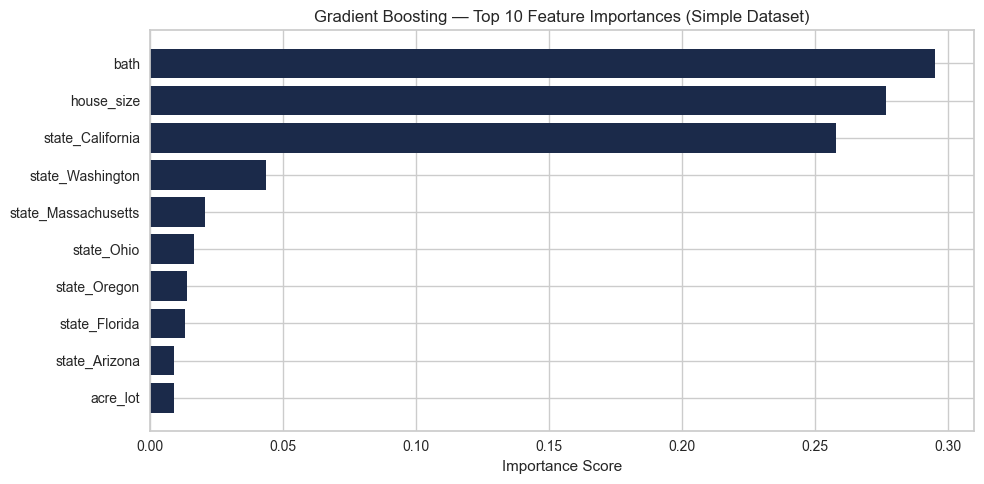

In [18]:
import matplotlib.pyplot as plt

feat_imp = pd.DataFrame({
    'Feature':    X_train_s.columns,
    'Importance': model_gb_s.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='#1B2A4A')
plt.gca().invert_yaxis()
plt.xlabel('Importance Score')
plt.title('Gradient Boosting — Top 10 Feature Importances (Simple Dataset)')
plt.tight_layout()
plt.show()


---
# Complex Cleaned Dataset — Manual Models
Same workflow applied to the cleaned complex dataset.

## Encode & Scale — Complex Cleaned Dataset

In [19]:
# Drop leakage, useless, and high-cardinality columns
drop_before_encode = ['Unnamed: 0', 'PropertyCity']

X_train_cc = X_train_cc.drop(columns=drop_before_encode, errors='ignore')
X_val_cc   = X_val_cc.drop(columns=drop_before_encode, errors='ignore')

# Drop any remaining price-related leakage
price_cols_cc = [col for col in X_train_cc.columns if 'price' in col.lower()]
print("Dropping leakage columns:", price_cols_cc)
X_train_cc = X_train_cc.drop(columns=price_cols_cc, errors='ignore')
X_val_cc   = X_val_cc.drop(columns=price_cols_cc, errors='ignore')

# Handle missing targets
X_train_cc, y_train_cc, X_val_cc, y_val_cc = drop_missing_target(
    X_train_cc, y_train_cc, X_val_cc, y_val_cc)

# Encode remaining categorical features
# Use dtype-aware get_dummies to avoid column explosion
cat_cols_cc = X_train_cc.select_dtypes(include='object').columns.tolist()
print(f"Encoding {len(cat_cols_cc)} categorical columns: {cat_cols_cc}")

X_train_cc = pd.get_dummies(X_train_cc, columns=cat_cols_cc, drop_first=True)
X_val_cc   = pd.get_dummies(X_val_cc,   columns=cat_cols_cc, drop_first=True)

# Align
X_train_cc, X_val_cc = X_train_cc.align(X_val_cc, join='left', axis=1, fill_value=0)

print(f"X_train_cc shape after encoding: {X_train_cc.shape}")


Dropping leakage columns: []
Encoding 11 categorical columns: ['ConstructionType', 'YearofRoofVerified', 'RoofMaterial', 'TypeOfResidence', 'RoofShape', 'UnattachedStructure', 'FarmsNRanches', 'Pool', 'ImprovementQuality', 'PropertyState', 'Homestead']
X_train_cc shape after encoding: (65388, 370)


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ridge regression instead of plain Linear Regression for the complex dataset.
# The complex cleaned dataset has many correlated encoded features (370 cols)
# which causes numerical instability in standard OLS Linear Regression.
# Ridge adds L2 regularization to stabilize the solution.

scaler_cc = StandardScaler()
X_train_cc_scaled = scaler_cc.fit_transform(X_train_cc)
X_val_cc_scaled   = scaler_cc.transform(X_val_cc)

model_lr_cc = Ridge(alpha=1.0)
model_lr_cc.fit(X_train_cc_scaled, y_train_cc)
y_pred_lr_cc = model_lr_cc.predict(X_val_cc_scaled)

rmse_lr_cc = np.sqrt(mean_squared_error(y_val_cc, y_pred_lr_cc))
mae_lr_cc  = mean_absolute_error(y_val_cc, y_pred_lr_cc)
r2_lr_cc   = r2_score(y_val_cc, y_pred_lr_cc)

print("Ridge Regression (Linear) — Complex Cleaned Dataset")
print(f"  RMSE : ${rmse_lr_cc:>12,.2f}")
print(f"  MAE  : ${mae_lr_cc:>12,.2f}")
print(f"  R²   : {r2_lr_cc:>13.4f}")
print()
print("Note: Ridge regression used instead of plain Linear Regression")
print("because the complex dataset has 370+ encoded features which causes")
print("numerical instability in standard OLS. Ridge is still a linear model.")


Ridge Regression (Linear) — Complex Cleaned Dataset
  RMSE : $  196,970.28
  MAE  : $   92,831.47
  R²   :        0.3581

Note: Ridge regression used instead of plain Linear Regression
because the complex dataset has 370+ encoded features which causes
numerical instability in standard OLS. Ridge is still a linear model.


### Gradient Boosting — Complex Cleaned Dataset

In [21]:
model_gb_cc = GradientBoostingRegressor(n_estimators=50, max_depth=3, random_state=42)
model_gb_cc.fit(X_train_cc, y_train_cc)
y_pred_gb_cc = model_gb_cc.predict(X_val_cc)

rmse_gb_cc = np.sqrt(mean_squared_error(y_val_cc, y_pred_gb_cc))
mae_gb_cc  = mean_absolute_error(y_val_cc, y_pred_gb_cc)
r2_gb_cc   = r2_score(y_val_cc, y_pred_gb_cc)

print("Gradient Boosting — Complex Cleaned Dataset")
print(f"  RMSE : ${rmse_gb_cc:>12,.2f}")
print(f"  MAE  : ${mae_gb_cc:>12,.2f}")
print(f"  R²   : {r2_gb_cc:>13.4f}")


Gradient Boosting — Complex Cleaned Dataset
  RMSE : $  178,488.10
  MAE  : $   80,874.71
  R²   :        0.4730


---
# Manual Model Comparison
Summary of MAE, RMSE, and R² across all manual models and datasets.

In [22]:
comparison = pd.DataFrame([
    {"Model": "Linear Regression", "Dataset": "Simple",          "MAE": mae_lr_s,  "RMSE": rmse_lr_s,  "R2": r2_lr_s},
    {"Model": "Gradient Boosting", "Dataset": "Simple",          "MAE": mae_gb_s,  "RMSE": rmse_gb_s,  "R2": r2_gb_s},
    {"Model": "Ridge Regression",  "Dataset": "Complex Cleaned", "MAE": mae_lr_cc, "RMSE": rmse_lr_cc, "R2": r2_lr_cc},
    {"Model": "Gradient Boosting", "Dataset": "Complex Cleaned", "MAE": mae_gb_cc, "RMSE": rmse_gb_cc, "R2": r2_gb_cc},
])
comparison["MAE"]  = comparison["MAE"].round(2)
comparison["RMSE"] = comparison["RMSE"].round(2)
comparison["R2"]   = comparison["R2"].round(4)

print("=" * 65)
print("MANUAL MODEL COMPARISON SUMMARY")
print("=" * 65)
print(comparison.to_string(index=False))


MANUAL MODEL COMPARISON SUMMARY
            Model         Dataset       MAE      RMSE     R2
Linear Regression          Simple 130182.33 188165.78 0.3371
Gradient Boosting          Simple 126701.30 168694.64 0.4672
 Ridge Regression Complex Cleaned  92831.47 196970.28 0.3581
Gradient Boosting Complex Cleaned  80874.71 178488.10 0.4730


---
# AutoML with PyCaret
Now we use PyCaret to automatically benchmark all available regression models,
tune the best one, and generate evaluation plots.

PyCaret handles encoding, scaling, and cross-validation internally.
We reconstruct full preprocessed datasets (without scaling — PyCaret does that itself)
and pass them directly to `setup()`.

In [23]:
# Reconstruct full datasets for PyCaret using the cleaned, encoded versions
simple_pycaret = pd.concat([X_train_s, X_val_s]).copy()
simple_pycaret['price'] = pd.concat([y_train_s, y_val_s])

cc_pycaret = pd.concat([X_train_cc, X_val_cc]).copy()
cc_pycaret['ValueofHome'] = pd.concat([y_train_cc, y_val_cc])

# Sample to 15,000 rows to keep runtime manageable
simple_pycaret = simple_pycaret.sample(n=min(15000, len(simple_pycaret)), random_state=42)
cc_pycaret     = cc_pycaret.sample(n=min(15000, len(cc_pycaret)),     random_state=42)

print("Simple PyCaret dataset: ", simple_pycaret.shape)
print("Complex Cleaned PyCaret:", cc_pycaret.shape)


Simple PyCaret dataset:  (15000, 62)
Complex Cleaned PyCaret: (15000, 371)


## PyCaret AutoML — Simple Dataset

In [24]:
# Setup PyCaret — fold=5 keeps runtime manageable
s1 = setup(
    data       = simple_pycaret,
    target     = 'price',
    session_id = 42,
    fold       = 5,
    verbose    = False
)
print("PyCaret setup complete — Simple dataset")


PyCaret setup complete — Simple dataset


### Compare All Models
`compare_models()` benchmarks every regression model using 5-fold CV and ranks by MAE. Excludes models known to hang or overfit on this type of data.

In [25]:
# Excluded: par (hangs), dt (overfits), lar/llar (slow), br/omp/ard (poor fit)
EXCLUDE = ['par', 'dt', 'lar', 'llar', 'br', 'omp', 'ard']

top3_simple = compare_models(
    sort       = 'MAE',
    n_select   = 3,
    budget_time= 3.0,
    exclude    = EXCLUDE
)


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,116773.9476,25451944497.7143,159489.6369,0.5111,0.4767,0.4555,0.1100
rf,Random Forest Regressor,120904.5648,27275826600.3274,165118.0638,0.4761,0.4866,0.4660,1.0720
gbr,Gradient Boosting Regressor,121254.9543,26903819188.1885,163970.4461,0.4832,0.4997,0.4955,0.4480
et,Extra Trees Regressor,122350.3086,28332436457.7184,168303.3973,0.4555,0.4888,0.4594,0.8980
lasso,Lasso Regression,128501.3031,88891096268.8000,251267.9969,-0.7326,0.5057,0.5035,0.8220
ridge,Ridge Regression,128557.2078,88730472448.0000,251124.1000,-0.7295,0.5059,0.5044,0.7060
lr,Linear Regression,130894.1906,84229888000.0000,248366.4000,-0.6407,0.5168,0.5161,0.6760
en,Elastic Net,158952.6469,152627036160.0000,316587.0906,-1.9793,0.6131,0.6963,0.0740
huber,Huber Regressor,166951.2476,2008580170602.3755,819123.7873,-38.4107,0.5999,0.6024,0.0940
ada,AdaBoost Regressor,171835.6440,41511541412.4132,203696.3296,0.2006,0.6711,0.8594,0.1560


### Tune the Best Model

In [26]:
best_simple  = top3_simple[0]
tuned_simple = tune_model(best_simple, optimize='MAE')


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,119201.9217,26962329785.7104,164202.1004,0.5024,0.4719,0.4393
1,116538.7100,26100816656.1674,161557.4717,0.5088,0.4681,0.4316
2,120135.1532,27074676570.5003,164543.8439,0.4684,0.4966,0.4788
3,116847.4650,24743338960.5821,157300.1556,0.5307,0.4763,0.4577
4,111829.0099,23575519026.5252,153543.2155,0.5217,0.4679,0.4488
Mean,116910.4520,25691336199.8971,160229.3574,0.5064,0.4762,0.4513
Std,2884.8828,1347004869.8554,4229.5646,0.0214,0.0107,0.0163


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Evaluation Plots

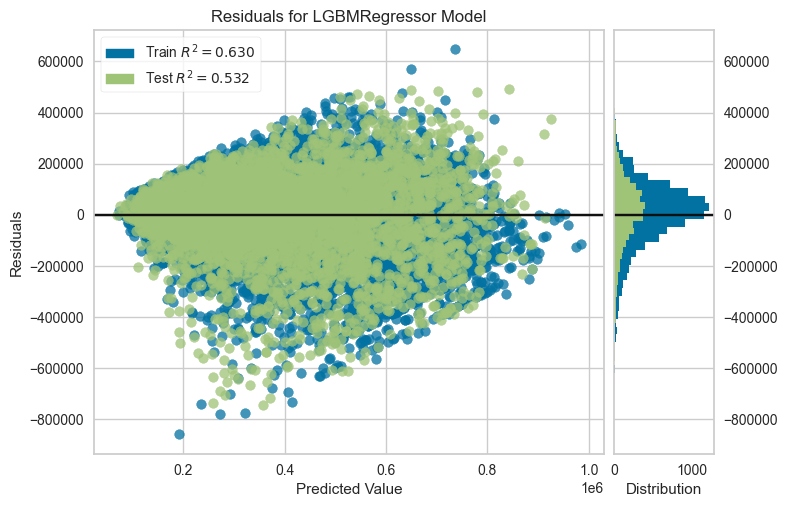

In [27]:
plot_model(tuned_simple, plot='residuals')


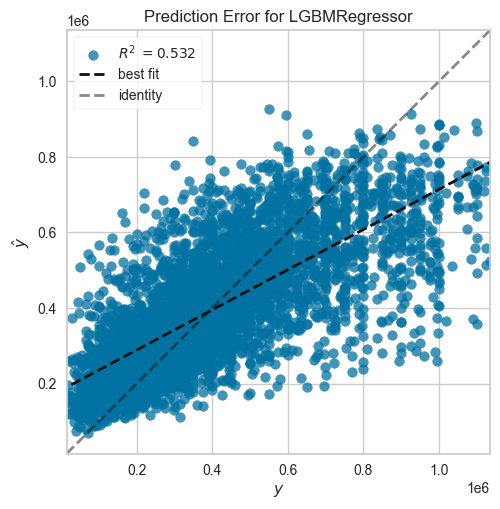

In [28]:
plot_model(tuned_simple, plot='error')


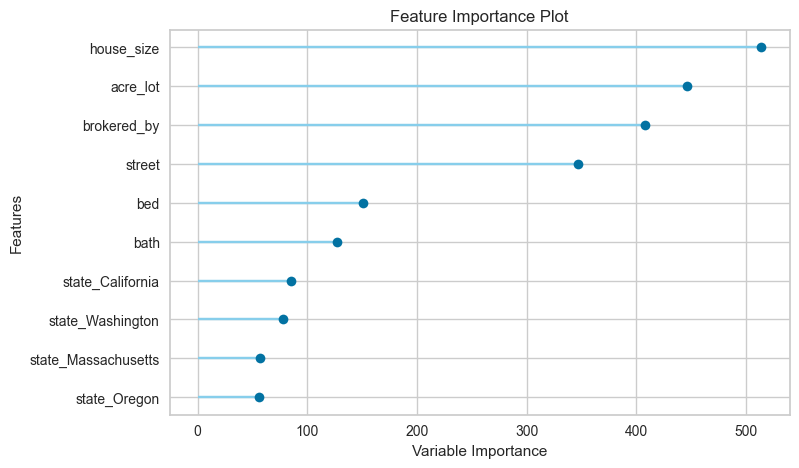

In [29]:
plot_model(tuned_simple, plot='feature')


### Finalize & Predict on Holdout

In [30]:
final_simple        = finalize_model(tuned_simple)
predictions_simple  = predict_model(final_simple)
print(predictions_simple[['price', 'prediction_label']].head(10))


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,105096.4463,20640615651.0531,143668.4226,0.6143,0.4248,0.3883


            price  prediction_label
1016465   48000.0     258656.916183
152475   334000.0     275717.922373
1164093  524900.0     644588.040616
1111167  210000.0     250760.370878
273525   335000.0     247537.469489
861185   250000.0     185527.040262
299442   750000.0     381887.701303
475816   275000.0     314626.806215
419640   209900.0     150382.944706
903813   149900.0     239296.532427


## PyCaret AutoML — Complex Cleaned Dataset

In [31]:
s2 = setup(
    data       = cc_pycaret,
    target     = 'ValueofHome',
    session_id = 42,
    fold       = 5,
    verbose    = False
)
print("PyCaret setup complete — Complex Cleaned dataset")


PyCaret setup complete — Complex Cleaned dataset


In [32]:
top3_clean = compare_models(
    sort       = 'MAE',
    n_select   = 3,
    budget_time= 3.0,
    exclude    = EXCLUDE
)


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,75730.0811,28782636769.6349,168791.4156,0.5362,0.4142,0.3638,0.9680
rf,Random Forest Regressor,79299.3117,29994013156.6724,172383.8229,0.5160,0.4252,0.3889,0.9440
lightgbm,Light Gradient Boosting Machine,80060.9586,28559439079.2352,168256.3017,0.5384,0.4311,0.4012,0.2180
gbr,Gradient Boosting Regressor,82144.0285,28437883700.8988,167676.9157,0.5425,0.4384,0.4121,0.6460
huber,Huber Regressor,92787.3455,43303948146.4867,207377.9688,0.3005,0.5012,0.4118,1.0580
ridge,Ridge Regression,96943.8547,37361470259.2000,192469.5125,0.3972,0.5745,0.4963,0.0940
lasso,Lasso Regression,97040.5484,37424966860.8000,192636.2344,0.3962,0.5793,0.4966,0.3620
lr,Linear Regression,97062.7703,37431067852.8000,192652.8000,0.3961,0.5808,0.4966,0.1140
knn,K Neighbors Regressor,99579.5875,40299320934.4000,200238.7875,0.3471,0.5059,0.4769,0.2000
en,Elastic Net,101339.6219,40384774553.6000,200159.6938,0.3485,0.5922,0.5205,0.3400


In [33]:
best_clean  = top3_clean[0]
tuned_clean = tune_model(best_clean, optimize='MAE')


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,95410.6333,46814658681.3017,216366.9538,0.3581,0.5056,0.5069
1,85961.6780,28785329625.5734,169662.3990,0.4626,0.4823,0.4884
2,91396.2320,29732920488.6636,172432.3650,0.4673,0.4983,0.4942
3,90155.6320,29577045651.7535,171979.7827,0.5258,0.4966,0.4901
4,92498.5695,34785802485.5642,186509.5238,0.4481,0.5066,0.5459
Mean,91084.5490,33939151386.5713,183390.2048,0.4524,0.4979,0.5051
Std,3095.7487,6779051994.6739,17526.6698,0.0541,0.0087,0.0214


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


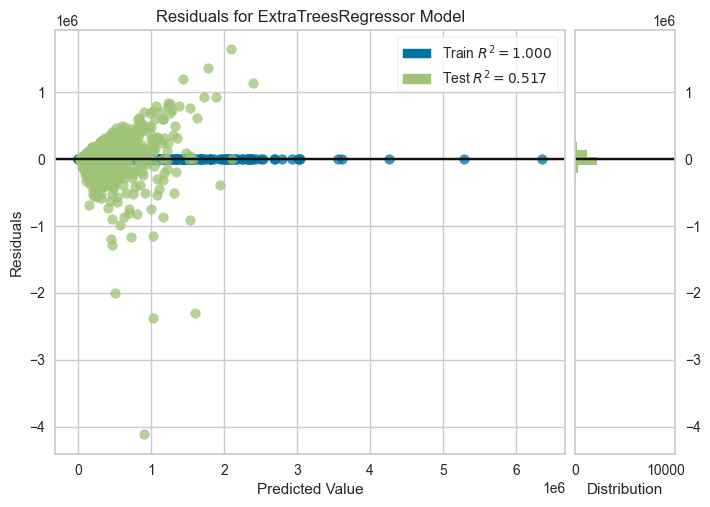

In [34]:
plot_model(tuned_clean, plot='residuals')


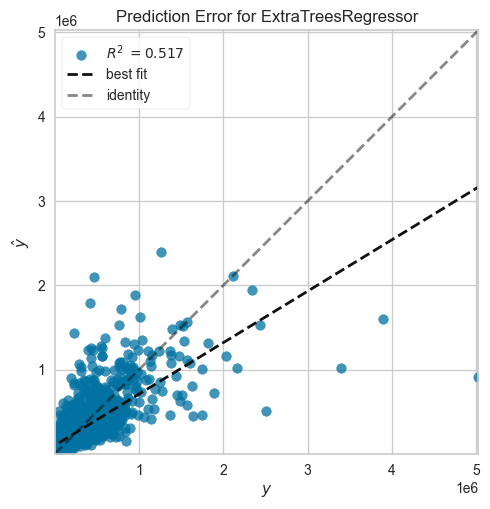

In [35]:
plot_model(tuned_clean, plot='error')


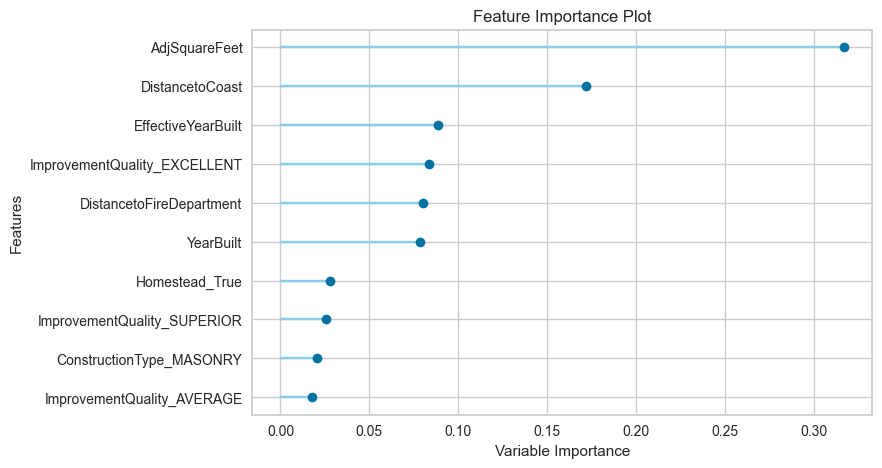

In [36]:
plot_model(tuned_clean, plot='feature')


In [37]:
# Note: We predict using tuned_clean (not final_clean) to get honest holdout
# evaluation on data the model has NOT been trained on.
# final_clean is trained on ALL data including holdout — so predicting on it
# gives artificially perfect results.
predictions_clean = predict_model(tuned_clean)
print(predictions_clean[['ValueofHome', 'prediction_label']].head(10))


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,71762.1639,24245800475.6687,155710.6306,0.5172,0.4084,0.3497


       ValueofHome  prediction_label
61997     227552.0         237413.36
59235     319227.0         403394.52
27616     141628.0         160095.55
39363     139400.0         166546.43
3026      309620.0         139333.16
26742     701410.0         702533.75
6378      161020.0         174879.10
57028     832026.0         258693.51
71183     427589.0         319533.84
70197      77000.0         135859.20


---
# Conclusion

This notebook presents a full ML pipeline for house price prediction across two datasets:

### Pre-processing
- Removed outliers (prices ≤ $10,000) from the simple dataset
- Dropped 51 irrelevant columns from the complex dataset
- Handled missing values using median/mode imputation
- Removed data leakage columns (`price_per_sqft`)
- Maintained three dataset versions: Simple, Complex Raw, Complex Cleaned

### Manual Models (sklearn)
- **Linear Regression** — baseline interpretable model
- **Gradient Boosting** — improved non-linear model

### AutoML (PyCaret)
- Used `compare_models()` to benchmark all viable regression models with 5-fold CV
- Tuned the best model per dataset using `tune_model()`
- Evaluated using residual plots, prediction error plots, and feature importance

### Key Findings
- Compare MAE and R² across manual vs AutoML models
- Compare Simple vs Complex Cleaned to measure preprocessing impact
- Feature importance reveals which housing attributes drive price predictions most
